1 pint ≈ 473 ml

½ pint ≈ 236 ml

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

bidDf = pd.read_csv('bid_rigging_df.xlsx - Sheet1.csv')





,Year,Market,Winner,WWBID,WWQTY,LFWBID,LFWQTY,LFCBID,LFCQTY,District,KYFMO,MilesM,MilesT,LetDate
0,1983,TRI-COUNTY,MEYER,"0,1260",76055,"0,126",81645,.,.,91,"0,0764",14,11,06/20/83
1,1983,TRI-COUNTY,TRAUTH,"0,1495",626,"0,1395",30702,.,.,452,"0,0764",4,0,06/02/83
2,1983,SURROUND,HILL'S DAIRY,"0,1400",.,"0,135",.,"0,143",.,101,"0,0764",50,47,06/28/83
3,1983,TRI-COUNTY,TRAUTH,"0,1193",9026,"0,1113",8987,.,.,32,"0,0764",4,2,07/20/83
4,1983,TRI-COUNTY,MEYER,"0,1094",51404,"0,1094",292086,"0,1094",429493,134,"0,0764",3,1,07/06/83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1986,SURROUND,BORDEN,"0,1195",.,.,.,"0,1085",.,455,"0,07",63,60,07/11/86
96,1986,SURROUND,TRAUTH,"0,1250",.,"0,1125",.,"0,1115",.,471,"0,07",48,44,07/11/86
97,1986,SURROUND,LICKING VALLEY,"0,1330",.,"0,124",.,"0,128",.,481,"0,07",34,31,07/10/86
98,1986,SURROUND,WESTOVER,"0,1249",.,"0,119",.,"0,119",.,495,"0,07",96,93,07/14/86


In [ ]:
bidDf.head()

bidDf['Winner'] = (
    bidDf['Winner']
    .astype(str)
    .str.strip()
    .str.upper()
)
bidDf['Market'] = (
    bidDf['Market']
    .astype(str)
    .str.strip()
    .str.upper()
)
bidDf.head(100) # 0,100 => mean sdt(standard diversion): độ lệch chuẩn 0,1260	0,08 NA

In [2]:
print(bidDf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Year      392 non-null    int64 
 1   Market    392 non-null    object
 2   Winner    392 non-null    object
 3   WWBID     392 non-null    object
 4   WWQTY     392 non-null    object
 5   LFWBID    392 non-null    object
 6   LFWQTY    392 non-null    object
 7   LFCBID    392 non-null    object
 8   LFCQTY    392 non-null    object
 9   District  392 non-null    int64 
 10  KYFMO     392 non-null    object
 11  MilesM    392 non-null    int64 
 12  MilesT    392 non-null    int64 
 13  LetDate   392 non-null    object
dtypes: int64(4), object(10)
memory usage: 43.0+ KB
None


In [13]:
# Pre Processing Data

preBidDf = bidDf.copy()


numeric_cols = [
    'WWBID','WWQTY',
    'LFWBID','LFWQTY',
    'LFCBID','LFCQTY',
    'KYFMO','MilesM','MilesT'
]


preBidDf[numeric_cols] = preBidDf[numeric_cols].replace('.', pd.NA)

preBidDf[numeric_cols] = preBidDf[numeric_cols].replace(',', '.', regex=True)

preBidDf[numeric_cols] = preBidDf[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)


preBidDf['invalid_bid'] = (
    (preBidDf['WWQTY'].notna() & preBidDf['WWBID'].isna()) |
    (preBidDf['LFWQTY'].notna() & preBidDf['LFWBID'].isna()) |
    (preBidDf['LFCQTY'].notna() & preBidDf['LFCBID'].isna())
)


preBidDf[preBidDf['invalid_bid'] == True]
preBidDf[['KYFMO','MilesM', 'MilesT']].info()

preBidDf.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KYFMO   392 non-null    float64
 1   MilesM  392 non-null    int64  
 2   MilesT  392 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 9.3 KB


,Year,Market,Winner,WWBID,WWQTY,LFWBID,LFWQTY,LFCBID,LFCQTY,District,KYFMO,MilesM,MilesT,LetDate,invalid_bid
0,1983,TRI-COUNTY,MEYER,0.1260,76055.0,0.1260,81645.0,NaN,NaN,91,0.0764,14,11,06/20/83,False
1,1983,TRI-COUNTY,TRAUTH,0.1495,626.0,0.1395,30702.0,NaN,NaN,452,0.0764,4,0,06/02/83,False
2,1983,SURROUND,HILL'S DAIRY,0.1400,NaN,0.1350,NaN,0.1430,NaN,101,0.0764,50,47,06/28/83,False
3,1983,TRI-COUNTY,TRAUTH,0.1193,9026.0,0.1113,8987.0,NaN,NaN,32,0.0764,4,2,07/20/83,False
4,1983,TRI-COUNTY,MEYER,0.1094,51404.0,0.1094,292086.0,0.1094,429493.0,134,0.0764,3,1,07/06/83,False


In [ ]:
marketBidDf = bidDf.groupby(['Market', 'Year','Winner']).size().reset_index(name='win_count')
print(type(marketBidDf))
marketBidDf.head(30)

plt.figure(figsize=(10,6))

marketBidDf[marketBidDf['Winner'] == 'MEYER'].head(30)

uniqueMarkets = bidDf['Market'].unique()
uniqueMarkets.sort()
count = 0
fig, axes = plt.subplots(1, len(uniqueMarkets), figsize=(14,6))
for market in uniqueMarkets:
    eachMarketDf = marketBidDf[marketBidDf['Market'] == market]
    uniqueWinners = eachMarketDf['Winner'].unique()
    for winner in uniqueWinners:
        marketWinnerDf = eachMarketDf[eachMarketDf['Winner'] == winner]
        axes[count].plot(
            marketWinnerDf['Year'],
            marketWinnerDf['win_count'],
            marker='o',
            label=winner
        )
    axes[count].set_title(f'Winning Distribution of {market}')
    axes[count].set_xlabel('Year')
    axes[count].set_ylabel('Win Count')

    axes[count].legend() 
    count += 1

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>


,Market,Year,Winner,win_count
0,SURROUND,1983,BORDEN,4
1,SURROUND,1983,CLOVERLEAF,5
2,SURROUND,1983,DEAN'S MILK,1
3,SURROUND,1983,FLAV-O-RICH,7
4,SURROUND,1983,HILL'S DAIRY,1
5,SURROUND,1983,HOLLAND,1
6,SURROUND,1983,KRAFT,1
7,SURROUND,1983,ROYAL CREST,1
8,SURROUND,1983,SOUTHERN BELLE,2
9,SURROUND,1983,THOMPSON-GLASS,1


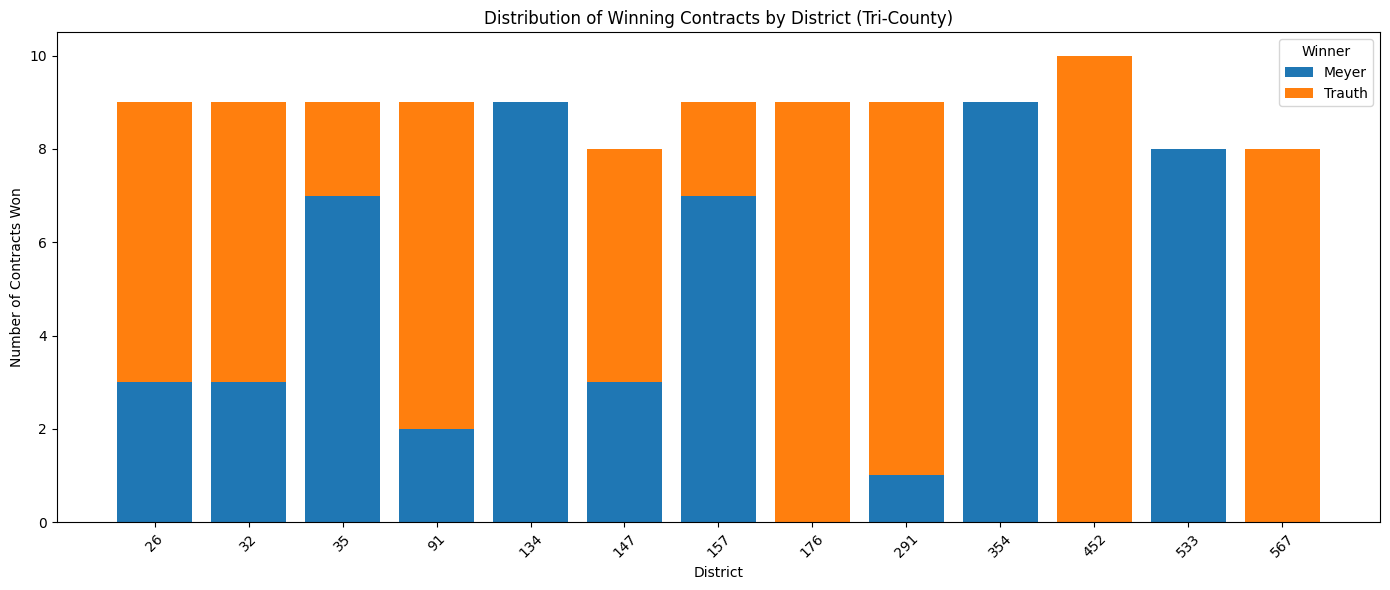

In [5]:
import numpy as np
import matplotlib.pyplot as plt

triCountyBidDf = bidDf[bidDf['Market'] == 'TRI-COUNTY']
triCountyBidDf

districtWinnerDf = (
    triCountyBidDf
    .groupby(['District', 'Winner'])
    .size()
    .unstack(fill_value=0)
)

districtWinnerDf

# Tạo vị trí x dạng category
x = np.arange(len(districtWinnerDf.index))

plt.figure(figsize=(14, 6))

plt.bar(
    x,
    districtWinnerDf['MEYER'],
    label='Meyer'
)

plt.bar(
    x,
    districtWinnerDf['TRAUTH'],
    bottom=districtWinnerDf['MEYER'],
    label='Trauth'
)

plt.title('Distribution of Winning Contracts by District (Tri-County)')
plt.xlabel('District')
plt.ylabel('Number of Contracts Won')

plt.xticks(x, districtWinnerDf.index, rotation=45)
plt.legend(title='Winner')

plt.tight_layout()
plt.show()

In [6]:
marketBidDf = bidDf.groupby(['Market', 'Year', 'District', 'Winner']) # DataFrameGroupBy
marketBidDf = marketBidDf.size() # Series
marketBidDf = marketBidDf.reset_index(name='win_count') # Dataframe
print(type(marketBidDf))
marketBidDf


surroundBidDf = bidDf[bidDf['Market'] == 'SURROUND']
surroundDistrictWinner = surroundBidDf.groupby(['Year', 'Winner']) # DataFrameGroupBy
surroundDistrictWinner = surroundDistrictWinner.size() # Series
surroundDistrictWinner = surroundDistrictWinner.unstack(fill_value=0) # DataFrame
print(type(surroundDistrictWinner))
surroundDistrictWinner

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


Winner,BORDEN,CLOVERLEAF,DEAN'S MILK,FLAV-O-RICH,FRENCH DIST.,HILL'S DAIRY,HOLLAND,J. W. HAYWOOD,KRAFT,LICKING VALLEY,MEYER,ROYAL CREST,SEALTEST,SOUTHEASTERN,SOUTHERN BELLE,THOMPSON,THOMPSON-GLASS,TRAUTH,WESTOVER,WILSON DIST.
Year,,,,,,,,,,,,,,,,,,,,
1983,4,5,1,7,0,1,1,0,1,0,0,1,0,0,2,0,1,2,1,1
1984,6,7,0,3,0,1,1,0,2,0,2,0,1,0,3,0,1,0,1,0
1985,9,5,0,3,1,0,0,1,1,0,3,0,0,0,3,0,1,4,1,0
1986,6,6,0,3,0,1,1,2,0,1,1,0,1,1,4,0,1,7,2,0
1987,7,4,0,3,0,0,1,1,0,1,4,0,2,2,3,1,1,7,0,0
1988,7,4,0,6,0,0,0,0,0,1,4,0,1,2,3,0,1,8,0,0
1989,3,0,0,7,0,0,1,0,0,1,9,0,0,2,4,1,3,7,0,0
1990,0,0,0,3,0,0,0,2,0,1,11,0,0,2,3,1,2,10,0,0
1991,0,0,0,1,0,0,0,0,0,0,2,0,0,0,1,0,1,0,0,0


108
88
392
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


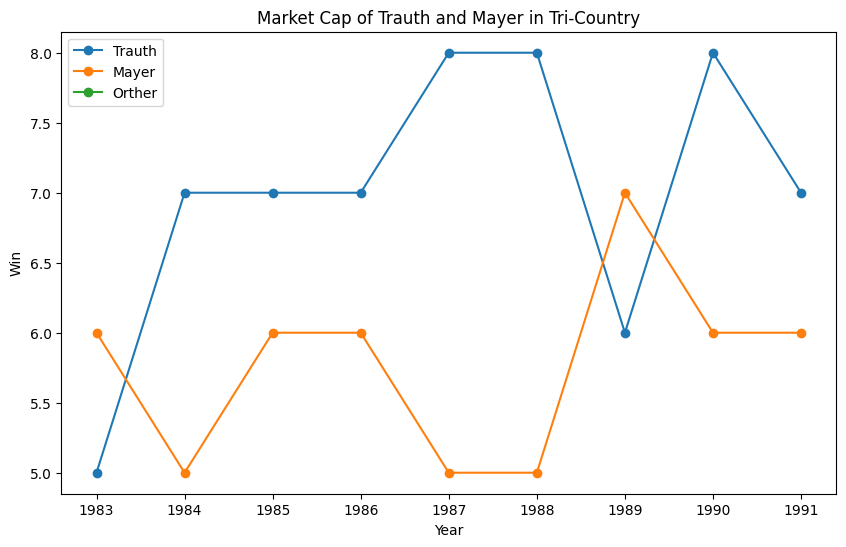

,Year,Market,Winner,WWBID,WWQTY,LFWBID,LFWQTY,LFCBID,LFCQTY,District,KYFMO,MilesM,MilesT,LetDate


In [7]:

# Câu 1:Tính toán thị phần của hai công ty Meyer và Trauth trong khu vực tri-county từ năm 1983 đến 1991.
# Hãy vẽ biểu đồ thể hiện sự thay đổi thị phần của hai công ty này theo thời gian. Phân tích xem có dấu hiệu nào của hành vi thông
# thầu (collusive behavior) hay không.

print(len(bidDf[bidDf['Winner'] == 'TRAUTH']))

print(len(bidDf[bidDf['Winner'] == 'MEYER']))

print(len(bidDf))


trauthTriCountryBidDf = bidDf[bidDf['Winner'] == 'TRAUTH']
trauthTriCountryBidDf = trauthTriCountryBidDf[trauthTriCountryBidDf['Market'] == 'TRI-COUNTY']
trauthTriCountryBidDf.head(30)


trauthTriCountryMarketCapDf = trauthTriCountryBidDf.groupby('Year')['Winner'].count().reset_index()
print(type(trauthTriCountryMarketCapDf))

mayerTriCountryBidDf = bidDf[bidDf['Winner'] == 'MEYER']
mayerTriCountryBidDf = mayerTriCountryBidDf[mayerTriCountryBidDf['Market'] == 'TRI-COUNTY']
mayerTriCountryBidDf.head(30)

mayerTriCountryMarketCapDf = mayerTriCountryBidDf.groupby('Year')['Winner'].count().reset_index()
print(type(mayerTriCountryMarketCapDf))


ortherTriCountryBidDf = bidDf[
    ~bidDf['Winner'].isin(['MEYER', 'TRAUTH'])
]
ortherTriCountryBidDf = ortherTriCountryBidDf[ortherTriCountryBidDf['Market'] == 'TRI-COUNTY']
ortherTriCountryMarketCapDf = ortherTriCountryBidDf.groupby('Year')['Winner'].count().reset_index()
print(type(ortherTriCountryBidDf))


plt.figure(figsize=(10,6))
plt.plot(trauthTriCountryMarketCapDf['Year'], trauthTriCountryMarketCapDf['Winner'], marker='o', label='Trauth')
plt.plot(mayerTriCountryMarketCapDf['Year'], mayerTriCountryMarketCapDf['Winner'], marker='o', label='Mayer')
plt.plot(ortherTriCountryMarketCapDf['Year'], ortherTriCountryMarketCapDf['Winner'], marker='o', label='Orther')
plt.title("Market Cap of Trauth and Mayer in Tri-Country")
plt.title("Market Cap of Trauth and Mayer in Tri-Country")
plt.xlabel('Year')
plt.ylabel('Win')
plt.legend()
plt.show()

ortherTriCountryBidDf.head(30)

In [8]:
bidDf[bidDf['Winner'] == 'MEYER'].groupby('Market').size()
bidDf[bidDf['Winner'] == 'TRAUTH'].groupby('Market').size()
bidDf['Market'].unique()

array(['TRI-COUNTY', 'SURROUND'], dtype=object)

387


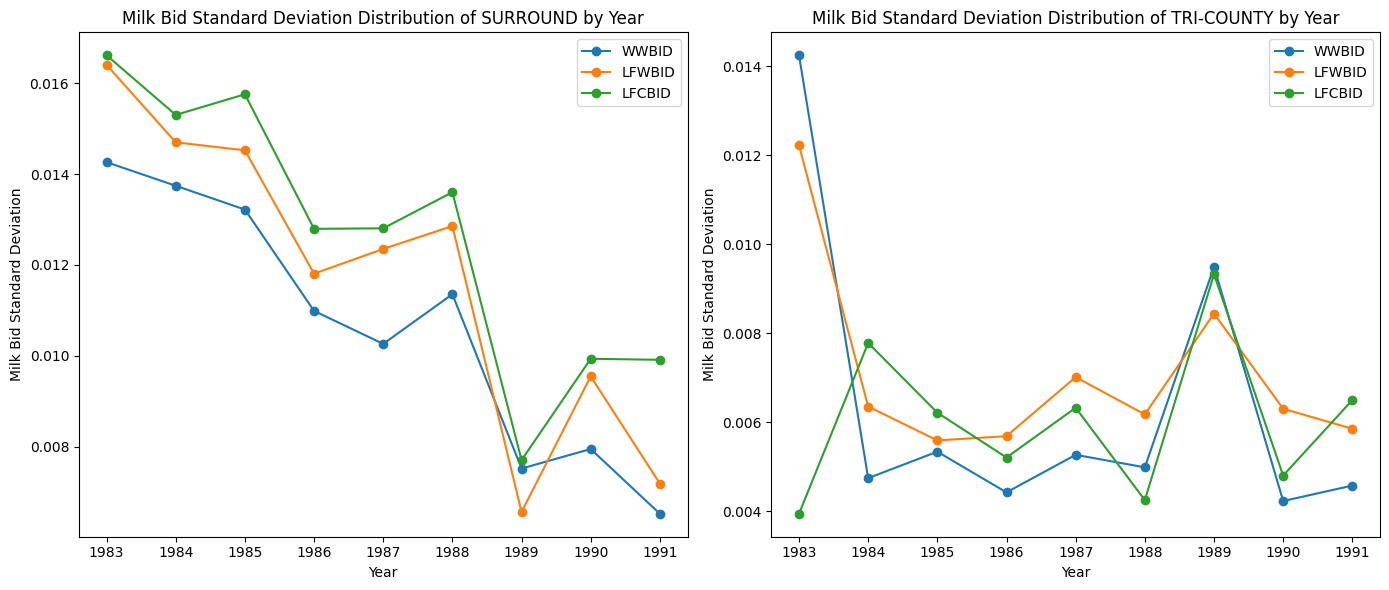

In [9]:
# Câu 3:Tính độ lệch chuẩn (standard deviation) của giá trúng thầu đối với từng loại sữa tại khu vực tri-county và surrounding từ
# năm 1983 đến 1991. Vẽ biểu đồ đường thể hiện xu hướng thay đổi độ lệch chuẩn theo thời gian. Đánh giá xem có dấu hiệu gì cho
# thấy thị trường có thể đang bị thông thầu hay không.

validBidDf = preBidDf[preBidDf['invalid_bid'] == False]
print(len(validBidDf))
validBidDf

uniqueMarkets = validBidDf['Market'].unique()
uniqueMarkets.sort()

bidMilkColumns = ['WWBID', 'LFWBID', 'LFCBID']

stdBidAggregateDf = validBidDf.groupby(['Year', 'Market'])[bidMilkColumns].std().reset_index()
stdBidAggregateDf

count = 0
fig, axes = plt.subplots(1, len(uniqueMarkets), figsize=(14,6))

for market in uniqueMarkets:
    eachMarketDf = stdBidAggregateDf[stdBidAggregateDf['Market'] == market]
    for col in bidMilkColumns:
        axes[count].plot(eachMarketDf['Year'],
                         eachMarketDf[col],
                         marker='o',label=col
                         )
    axes[count].set_title(f'Milk Bid Standard Deviation Distribution of {market} by Year')
    axes[count].set_xlabel('Year')
    axes[count].set_ylabel('Milk Bid Standard Deviation')

    axes[count].legend() 
    count += 1

plt.tight_layout()
plt.show()

387


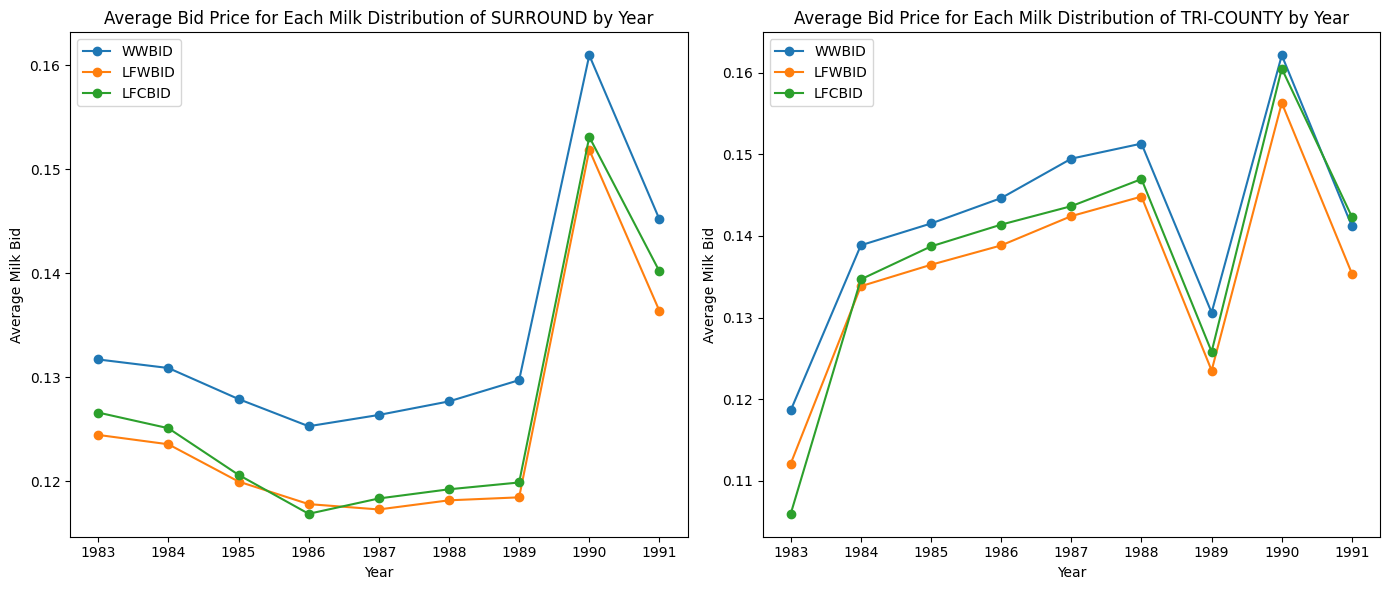

In [10]:
# Câu 4:Tính giá trúng thầu trung bình (average winning price) cho mỗi loại sữa tại khu vực tri-county và surrounding từ năm
# 1983 đến 1991.Vẽ biểu đồ đường thể hiện xu hướng thay đổi của giá trung bình theo thời gian. Phân tích các biểu đồ và đưa ra
# nhận định về khả năng thông thầu.

validBidDf = preBidDf[preBidDf['invalid_bid'] == False]
print(len(validBidDf))
validBidDf

uniqueMarkets = validBidDf['Market'].unique()
uniqueMarkets.sort()

bidMilkColumns = ['WWBID', 'LFWBID', 'LFCBID']

meanBidAggregateDf = validBidDf.groupby(['Year', 'Market'])[bidMilkColumns].mean().reset_index()
meanBidAggregateDf

count = 0
fig, axes = plt.subplots(1, len(uniqueMarkets), figsize=(14,6))

for market in uniqueMarkets:
    eachMarketDf = meanBidAggregateDf[meanBidAggregateDf['Market'] == market]
    for col in bidMilkColumns:
        axes[count].plot(eachMarketDf['Year'],
                         eachMarketDf[col],
                         marker='o',label=col
                         )
    axes[count].set_title(f'Average Bid Price for Each Milk Distribution of {market} by Year')
    axes[count].set_xlabel('Year')
    axes[count].set_ylabel('Average Milk Bid')

    axes[count].legend() 
    count += 1

plt.tight_layout()
plt.show()

352


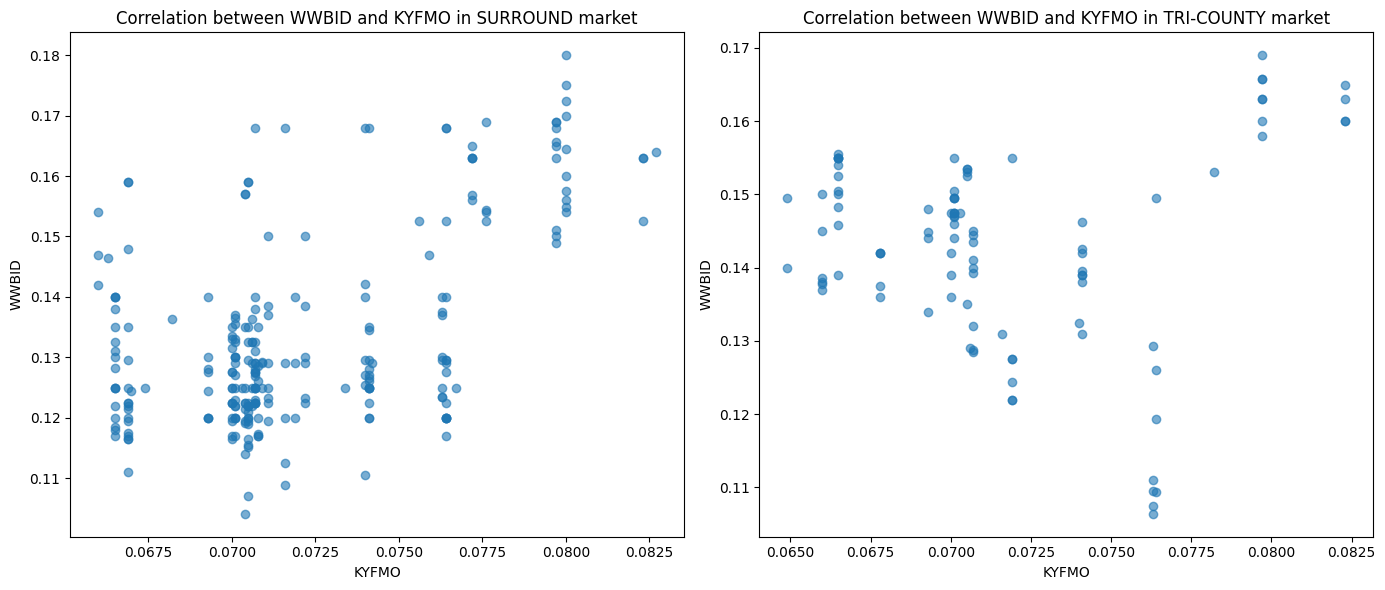

367


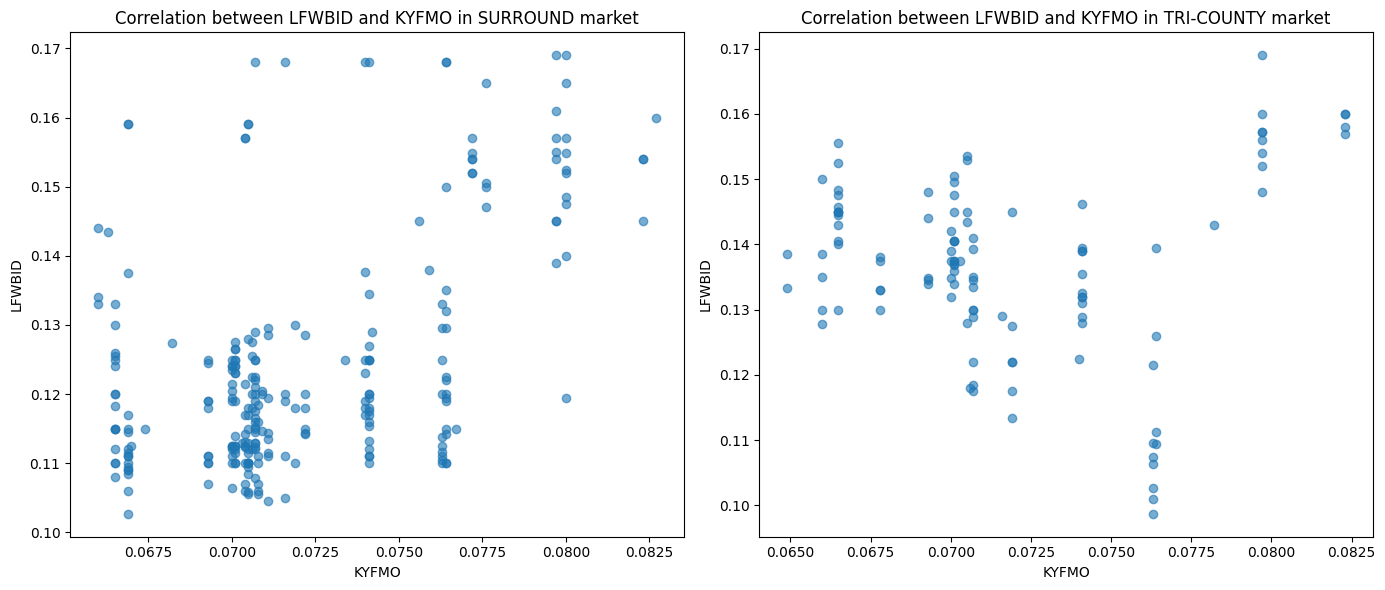

329


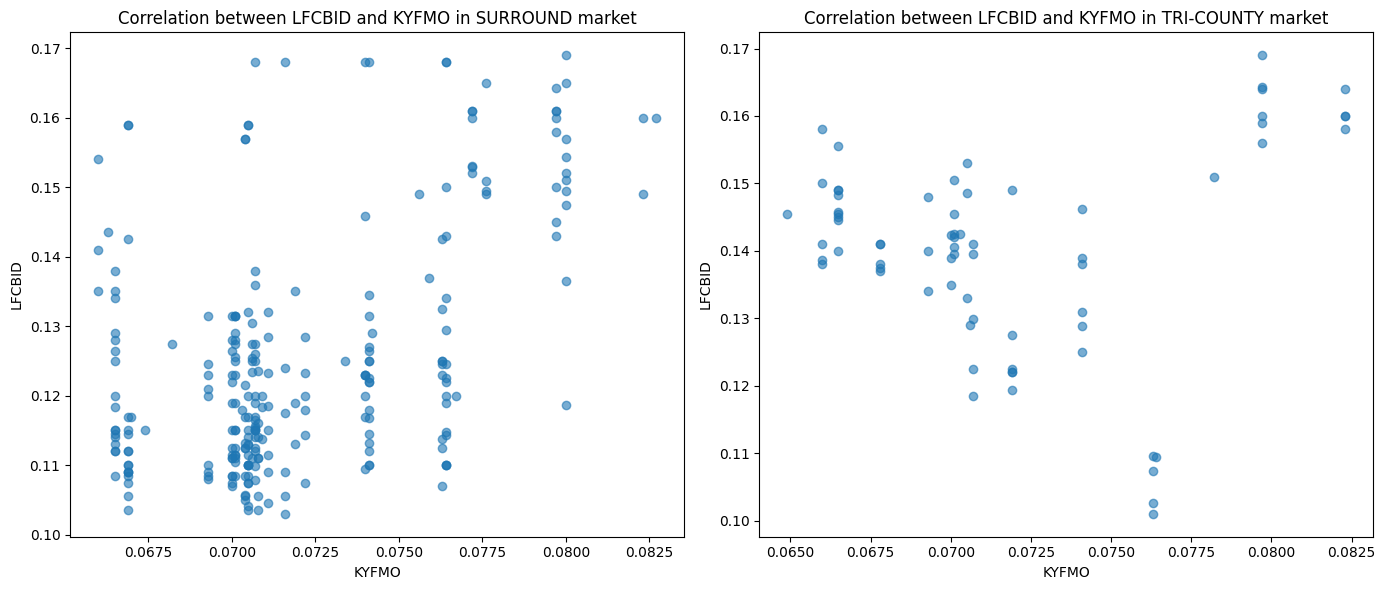

In [11]:
# Câu 5:Tiến hành phân tích hồi quy (regression analysis) để kiểm tra mối quan hệ giữa chi phí đầu vào (cost) và giá trúng thầu
# trung bình (average price) tại khu vực tri-county và surrounding. Vẽ biểu đồ phân tán (scatter plot) kèm phương trình hồi quy để
# minh họa. Phân tích và thảo luận về bất kỳ dấu hiệu nào cho thấy có thể tồn tại hành vi thông thầu.

bidMilkColumns = ['WWBID', 'LFWBID', 'LFCBID']
validDf = preBidDf[preBidDf['invalid_bid'] == False]

for milk in bidMilkColumns:
    milkDf = validDf[
        validDf[milk].notna() &
        validDf['KYFMO'].notna()
    ]
    print(len(milkDf))
    uniqueMarkets = milkDf['Market'].unique()
    uniqueMarkets.sort()

    fig, axes = plt.subplots(1, len(uniqueMarkets), figsize=(14,6))
    count = 0
    for market in uniqueMarkets:
        eachMarketDf = milkDf[milkDf['Market'] == market]
        axes[count].set_title(f'Correlation between {milk} and KYFMO in {market} market')
        axes[count].scatter(eachMarketDf['KYFMO'], eachMarketDf[milk], alpha=0.6)
        axes[count].set_xlabel('KYFMO')
        axes[count].set_ylabel(milk)
        count = count + 1

    plt.tight_layout()
    plt.show()